In [1]:
import pandas as pd

# 1. Mock Job-Post Event Data
raw_events = [
    {
        "event_id": "evt_101",
        "event_type": "job_post_submitted",
        "timestamp": "2026-08-20T10:00:00Z",
        "payload": {
            "job_id": "job_001",
            "recruiter_id": "rec_01",
            "title": "Data Analyst",
            "skill_thresholds": [
                {"skill": "SQL", "min_score": 80},
                {"skill": "Python", "min_score": 75}
            ]
        }
    },
    {
        "event_id": "evt_102",
        "event_type": "job_post_submitted",
        "timestamp": "2026-08-20T10:15:00Z",
        "payload": {
            "job_id": "job_002",
            "recruiter_id": "rec_02",
            "title": "Senior Data Analyst",
            "skill_thresholds": [
                {"skill": "SQL", "min_score": 90},
                {"skill": "Tableau", "min_score": 85}
            ]
        }
    }
]

df_events = pd.DataFrame(raw_events)

# 2. Validate Events
def validate_job_event(row):
    payload = row['payload']
    if not payload.get('job_id') or not payload.get('skill_thresholds'):
        return False
    for skill in payload['skill_thresholds']:
        if not (0 <= skill.get('min_score', -1) <= 100):
            return False
    return True

df_events['is_valid'] = df_events.apply(validate_job_event, axis=1)
df_validated = df_events[df_events['is_valid']].copy()

# 3. Create Live jobs_posted_view
jobs_data = []
for _, row in df_validated.iterrows():
    p = row['payload']
    for skill in p['skill_thresholds']:
        jobs_data.append({
            'job_id': p['job_id'],
            'title': p['title'],
            'recruiter_id': p['recruiter_id'],
            'posted_at': row['timestamp'],
            'skill_name': skill['skill'],
            'min_score_threshold': skill['min_score']
        })

jobs_posted_view = pd.DataFrame(jobs_data)
jobs_posted_view

,job_id,title,recruiter_id,posted_at,skill_name,min_score_threshold
0,job_001,Data Analyst,rec_01,2026-08-20T10:00:00Z,SQL,80
1,job_001,Data Analyst,rec_01,2026-08-20T10:00:00Z,Python,75
2,job_002,Senior Data Analyst,rec_02,2026-08-20T10:15:00Z,SQL,90
3,job_002,Senior Data Analyst,rec_02,2026-08-20T10:15:00Z,Tableau,85


In [2]:
# Summary metrics for job supply tracking
summary_by_skill = jobs_posted_view.groupby('skill_name').agg(
    total_postings=('job_id', 'nunique'),
    avg_min_score=('min_score_threshold', 'mean')
).reset_index()

print("--- Job Supply by Skill Thresholds ---")
display(summary_by_skill)

--- Job Supply by Skill Thresholds ---


,skill_name,total_postings,avg_min_score
0,Python,1,75.0
1,SQL,2,85.0
2,Tableau,1,85.0


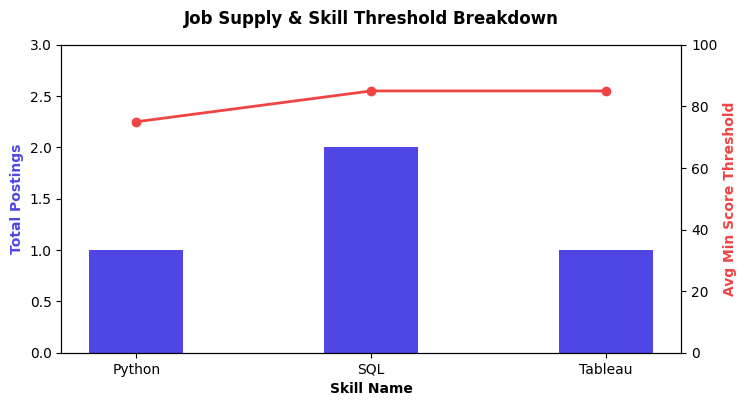

In [3]:
import matplotlib.pyplot as plt

# Create visualization for job supply & skill thresholds
fig, ax1 = plt.subplots(figsize=(8, 4))

# Bar chart for posting counts
ax1.bar(summary_by_skill['skill_name'], summary_by_skill['total_postings'], color='#4F46E5', width=0.4, label='Total Job Postings')
ax1.set_xlabel('Skill Name', fontweight='bold')
ax1.set_ylabel('Total Postings', color='#4F46E5', fontweight='bold')
ax1.set_ylim(0, max(summary_by_skill['total_postings']) + 1)

# Line plot overlay for average threshold score
ax2 = ax1.twinx()
ax2.plot(summary_by_skill['skill_name'], summary_by_skill['avg_min_score'], color='#EF4444', marker='o', linewidth=2, label='Avg Min Score')
ax2.set_ylabel('Avg Min Score Threshold', color='#EF4444', fontweight='bold')
ax2.set_ylim(0, 100)

plt.title('Job Supply & Skill Threshold Breakdown', fontsize=12, fontweight='bold', pad=15)
plt.show()